## total_data EDA
- 제거 항목
`라인` - ZD(사입), ZE (온라인), ZF(여성 →제외)
`품종` - 소품/ 언더웨어

In [35]:
import numpy as np   # 수학 연산 및 배열 계산
import pandas as pd  # 데이터 분석 및 처리
import random        # 난수 생성
import datetime      # 날짜 및 시간 데이터 처리
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
from matplotlib import rc 
rc('font', family='AppleGothic') 		
plt.rcParams['axes.unicode_minus'] = False

In [4]:
df = pd.read_csv('total_data.csv', index_col=2, parse_dates=True)
df

## 소품종/복종별로 본 것 안에 라인 
## a 트렌드 b 베이직 

,Unnamed: 0,기간,라인,성별,기획년도,시즌이월,상품년차,시즌,복종,소품종,...,매장재고택가,재고수량,재고원가,재고택가,기간입고수량,기간입고원가,기간입고택가,기간출고수량,기간출고원가,기간출고택가
주차,,,,,,,,,,,,,,,,,,,,,
2021-01-03,0,당해,ZB,1:남성,2021,01_시즌,당해년도,봄,우븐 셔츠,캐쥬얼셔츠,...,70319400,2244,19867080,156855600,0,0,0,53,469228,3704700
2021-01-03,1,당해,ZB,1:남성,2021,01_시즌,당해년도,사계절,소품,양말,...,25238400,10873,8915860,35880900,0,0,0,454,372280,1498200
2021-01-03,2,당해,ZB,1:남성,2021,01_시즌,당해년도,봄,니트 셔츠,라운드,...,387176100,19675,174679125,1375282500,0,0,0,5940,52713656,415206000
2021-01-03,3,당해,ZA,1:남성,2021,01_시즌,당해년도,사계절,소품,타이,...,204490200,5918,38644540,295308200,0,0,0,166,1083980,8283400
2021-01-03,4,당해,ZA,1:남성,2021,01_시즌,당해년도,봄,수트,블레이져(수트),...,112184000,345,22496751,130755000,0,0,0,6,391248,2274000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-29,51274,당해,ZA,1:남성,2024,01_시즌,당해년도,사계절,소품,타이,...,35035000,715,5577000,35035000,0,0,0,0,0,0
2024-12-29,51275,당해,ZB,1:남성,2024,01_시즌,당해년도,겨울,수트,수트팬츠,...,157791000,1132,30991123,168668000,0,0,0,15,410660,2235000
2024-12-29,51276,당해,ZB,1:남성,2024,02_이월,당해년도,여름,스웨터,라운드,...,0,677,10133232,67023000,0,0,0,0,0,0


In [5]:
df['복종'].unique()

array(['우븐 셔츠', '소품', '니트 셔츠', '수트', '스웨터', '가죽&FUR', '코트', '조끼', '팬츠',
       '점퍼', '데님', '자켓', '언더웨어', '사파리', '스커트'], dtype=object)

In [6]:
df['소품종'].unique()

array(['캐쥬얼셔츠', '양말', '라운드', '타이', '블레이져(수트)', '수트팬츠', '가죽점퍼', '벨트',
       '드레스셔츠', '더블코트', 'VEST', '패딩베스트', '오픈형(CARDIGAN)', 'T-에리', '싱글코트',
       '신발', '팬츠(일반)', '패딩점퍼', '데님팬츠', '싱글재킷', '점퍼', 'TOP', '이너웨어 민소매',
       '티에리', '반바지', '언더웨어 셋업', '니트팬츠', '패딩사파리', '오픈형티(맨투맨 등)', 'Turtle',
       'BOTTOM', '후드티', '데님자켓', '기타', '후드T', '라운드(V넥 등)', 'Short 스커트'],
      dtype=object)

## category_sum EDA
- `팬츠류` '팬츠_니트팬츠', '팬츠_반바지', '팬츠_팬츠(일반)', '데님_데님팬츠','데님_데님자켓',
 - '데님_데님자켓_ZB', '데님_데님팬츠_ZB'
 - '팬츠_니트팬츠_ZA', '팬츠_니트팬츠_ZB', '팬츠_니트팬츠_ZG'
 - '팬츠_반바지_ZA', '팬츠_반바지_ZB', '팬츠_반바지_ZG'
 - '팬츠_팬츠(일반)_ZA', '팬츠_팬츠(일반)_ZB', '팬츠_팬츠(일반)_ZG'

- 대품종 → 소품종 → 라인별 SUM(판매액, 판매수량, 매출원가,판매택가)
- 5가지 확인하기 : 판매량 추이 (수량) , 매출추이(판매액), 판매액/판매수량 → 판매가 , 판매택가/판매수량 → 택가 , 할인추이 ( 택가 - 판매가 = 할인가 → 할인율)

In [7]:
df2 = pd.read_csv('category_sum.csv', index_col=None)
df2


,Unnamed: 0,주차,카테고리,판매액,판매수량,매출원가,판매택가,실판매가,택가,할인율
0,0,2021-01-03,가죽&FUR_가죽점퍼_ZA,52297400,53,10846000,52947000,986743.396226,999000.000000,0.012269
1,1,2021-01-03,수트_블레이져(수트)_ZA,19685400,109,5717811,35131000,180600.000000,322302.752294,0.439657
2,2,2021-01-03,수트_수트팬츠_ZA,12921890,128,3853581,23232000,100952.265625,181500.000000,0.443789
3,4,2021-01-03,니트 셔츠_라운드_ZB,18981424,401,3559559,28029900,47335.221945,69900.000000,0.322815
4,5,2021-01-03,수트_블레이져(수트)_ZB,29890941,194,7913293,38606000,154077.015464,199000.000000,0.225744
...,...,...,...,...,...,...,...,...,...,...
12577,22007,2024-12-29,팬츠_팬츠(일반)_ZG,311565,5,85101,645000,62313.000000,129000.000000,0.516953
12578,22008,2024-12-29,니트 셔츠_라운드_ZG,0,0,0,0,0.000000,0.000000,0.000000
12579,22009,2024-12-29,점퍼_점퍼_ZG,0,0,0,0,0.000000,0.000000,0.000000
12580,22010,2024-12-29,팬츠_반바지_ZG,0,0,0,0,0.000000,0.000000,0.000000


In [8]:
df2.head()

,Unnamed: 0,주차,카테고리,판매액,판매수량,매출원가,판매택가,실판매가,택가,할인율
0,0,2021-01-03,가죽&FUR_가죽점퍼_ZA,52297400,53,10846000,52947000,986743.396226,999000.000000,0.012269
1,1,2021-01-03,수트_블레이져(수트)_ZA,19685400,109,5717811,35131000,180600.000000,322302.752294,0.439657
2,2,2021-01-03,수트_수트팬츠_ZA,12921890,128,3853581,23232000,100952.265625,181500.000000,0.443789
3,4,2021-01-03,니트 셔츠_라운드_ZB,18981424,401,3559559,28029900,47335.221945,69900.000000,0.322815
4,5,2021-01-03,수트_블레이져(수트)_ZB,29890941,194,7913293,38606000,154077.015464,199000.000000,0.225744


### 라인만 다른 애들끼리

- 팬츠 일반

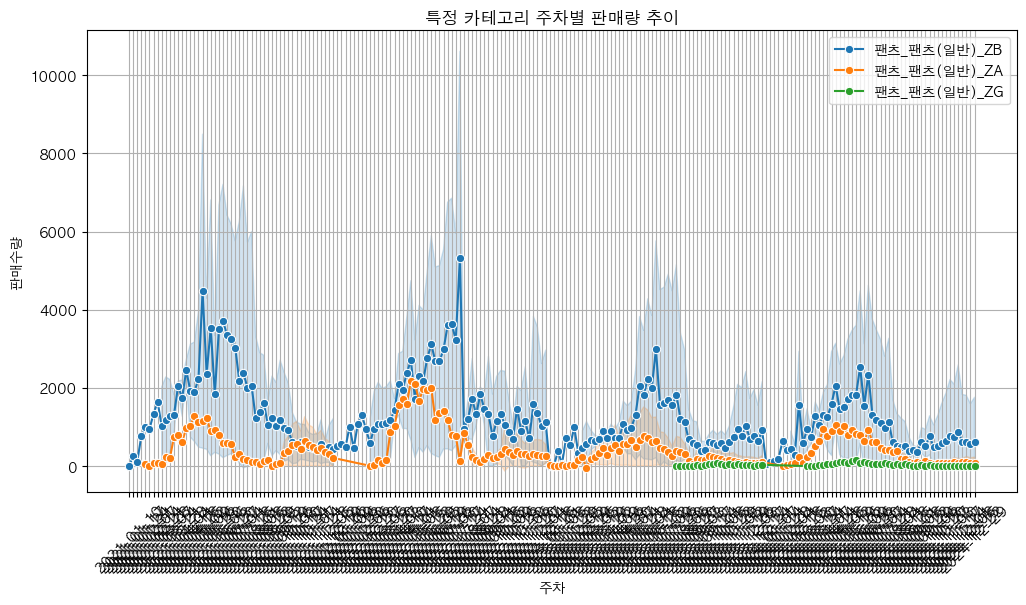

In [9]:
# 카테고리 선택
selected_categories = ['팬츠_팬츠(일반)_ZA', '팬츠_팬츠(일반)_ZB', '팬츠_팬츠(일반)_ZG'] 
df_selected = df2[df2["카테고리"].isin(selected_categories)]

plt.figure(figsize=(12, 6))

# Seaborn 라인 플롯
sns.lineplot(data=df_selected, x="주차", y="판매수량", hue="카테고리", marker="o")

plt.xlabel("주차")
plt.ylabel("판매수량")
plt.title("특정 카테고리 주차별 판매량 추이")
plt.xticks(rotation=45)
plt.grid()
plt.legend()

plt.show()


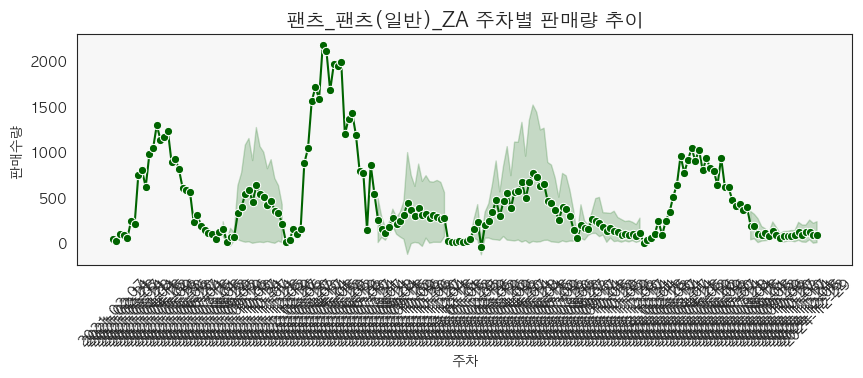

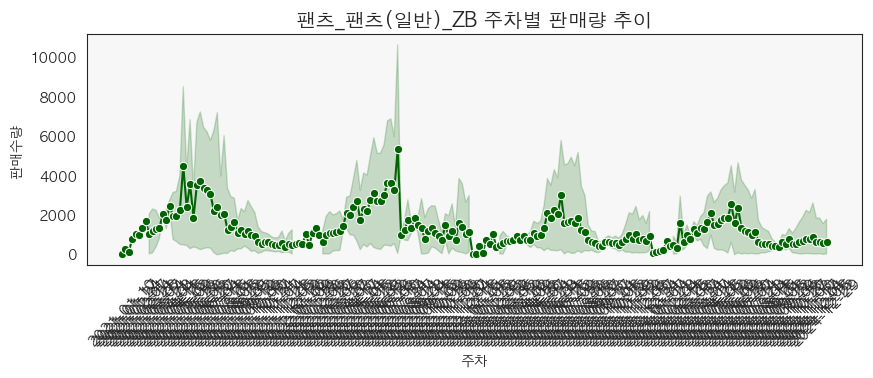

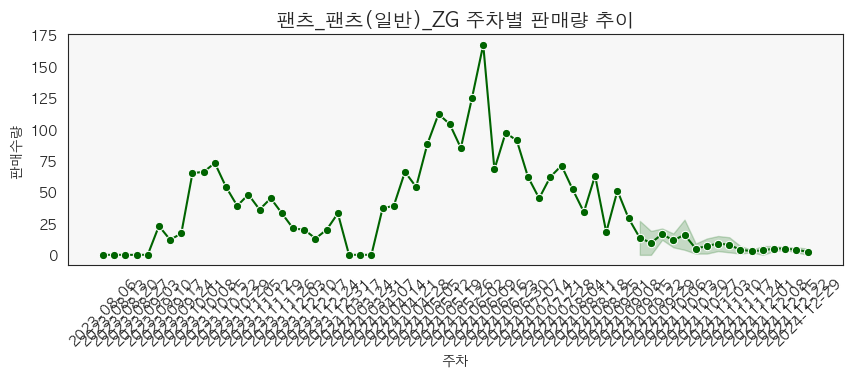

In [ ]:
# 카테고리 선택
selected_categories = ['팬츠_팬츠(일반)_ZA', '팬츠_팬츠(일반)_ZB', '팬츠_팬츠(일반)_ZG'] 

for category in selected_categories:
    df_filtered = df2[df2["카테고리"] == category]  # 특정 카테고리만 필터링

    plt.figure(figsize=(10, 3))
    
    # 진한 그린 컬러 설정
    ax = sns.lineplot(data=df_filtered, x="주차", y="판매수량", marker="o", color="#006400")  

    # 연한 회색 배경 설정
    ax.set_facecolor("#f7f7f7")

    plt.xlabel("주차")
    plt.ylabel("판매수량")
    plt.title(f"{category} 주차별 판매량 추이", fontsize=14, fontweight='bold')
    plt.xticks(rotation=45)
    plt.grid(False)  # 격자 제거

    plt.show()


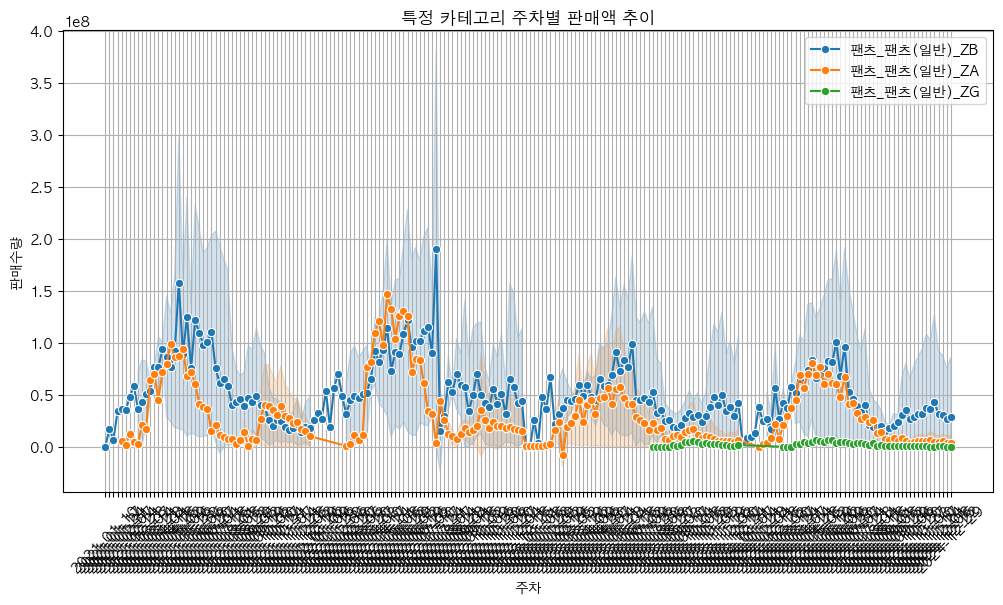

In [10]:
# 카테고리 선택
selected_categories = ['팬츠_팬츠(일반)_ZA', '팬츠_팬츠(일반)_ZB', '팬츠_팬츠(일반)_ZG'] 
df_selected = df2[df2["카테고리"].isin(selected_categories)]

plt.figure(figsize=(12, 6))

# Seaborn 라인 플롯
sns.lineplot(data=df_selected, x="주차", y="판매액", hue="카테고리", marker="o")

plt.xlabel("주차")
plt.ylabel("판매수량")
plt.title("특정 카테고리 주차별 판매액 추이")
plt.xticks(rotation=45)
plt.grid()
plt.legend()

plt.show()

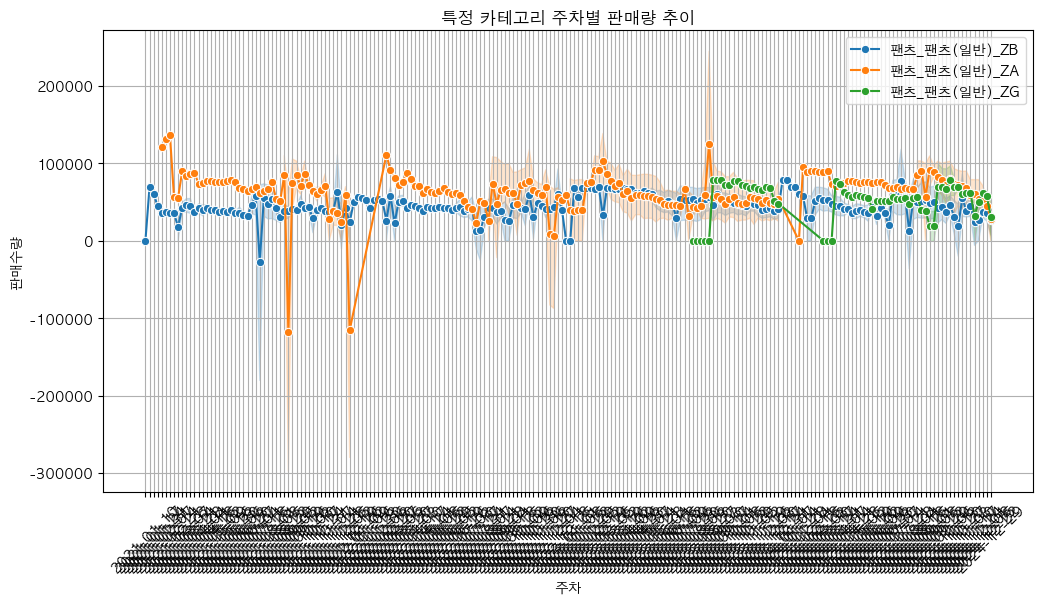

In [11]:
# 카테고리 선택
selected_categories = ['팬츠_팬츠(일반)_ZA', '팬츠_팬츠(일반)_ZB', '팬츠_팬츠(일반)_ZG'] 
df_selected = df2[df2["카테고리"].isin(selected_categories)]

plt.figure(figsize=(12, 6))

# Seaborn 라인 플롯
sns.lineplot(data=df_selected, x="주차", y="실판매가", hue="카테고리", marker="o")
plt.xlabel("주차")
plt.ylabel("판매수량")
plt.title("특정 카테고리 주차별 판매량 추이")
plt.xticks(rotation=45)
plt.grid()
plt.legend()

plt.show()

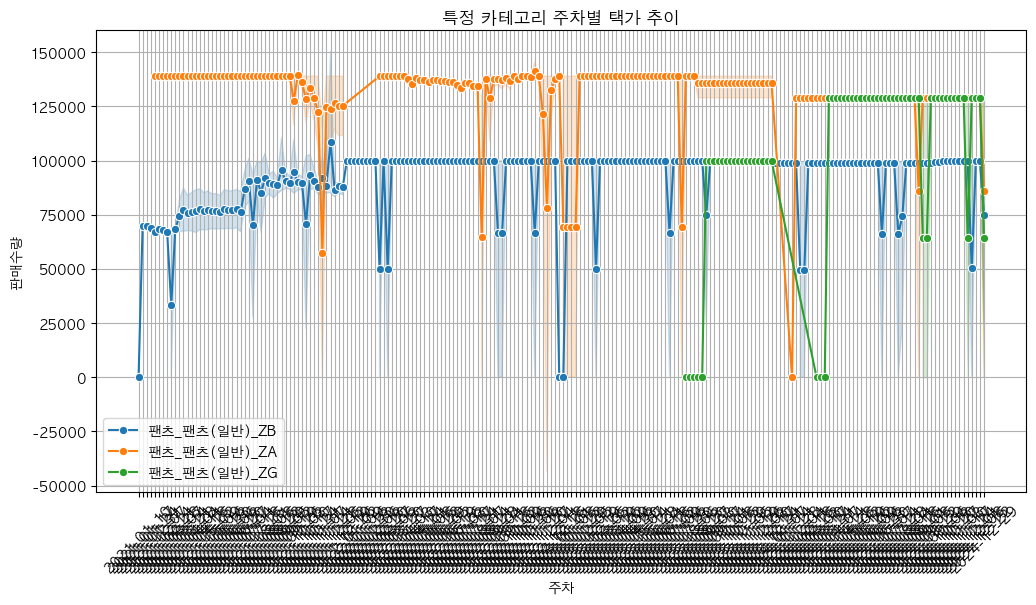

In [12]:
# 카테고리 선택
selected_categories = ['팬츠_팬츠(일반)_ZA', '팬츠_팬츠(일반)_ZB', '팬츠_팬츠(일반)_ZG'] 
df_selected = df2[df2["카테고리"].isin(selected_categories)]

plt.figure(figsize=(12, 6))

# Seaborn 라인 플롯
sns.lineplot(data=df_selected, x="주차", y="택가", hue="카테고리", marker="o")

plt.xlabel("주차")
plt.ylabel("판매수량")
plt.title("특정 카테고리 주차별 택가 추이")
plt.xticks(rotation=45)
plt.grid()
plt.legend()

plt.show()

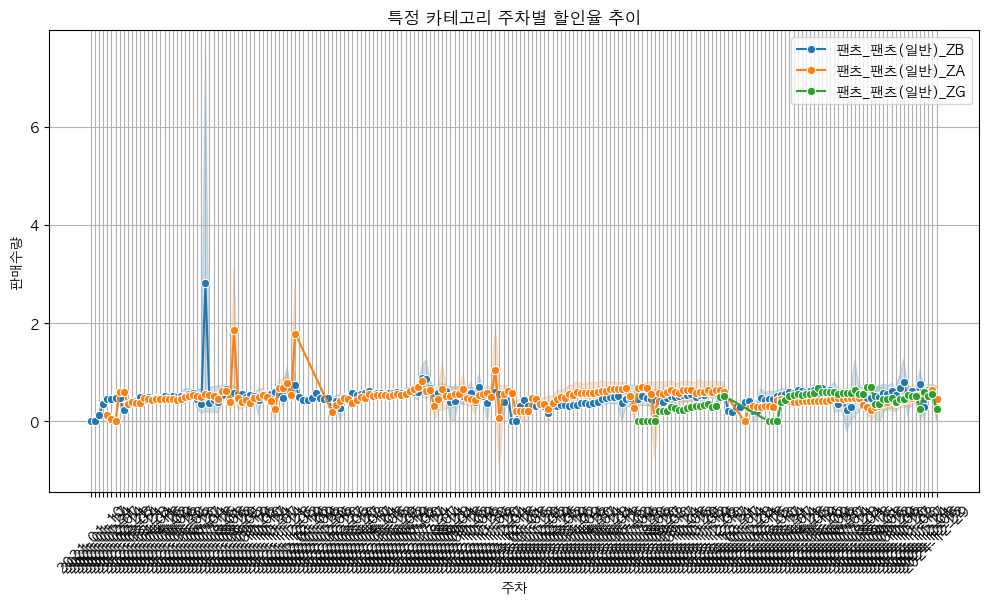

In [13]:
# 카테고리 선택
selected_categories = ['팬츠_팬츠(일반)_ZA', '팬츠_팬츠(일반)_ZB', '팬츠_팬츠(일반)_ZG'] 
df_selected = df2[df2["카테고리"].isin(selected_categories)]

plt.figure(figsize=(12, 6))

# Seaborn 라인 플롯
sns.lineplot(data=df_selected, x="주차", y="할인율", hue="카테고리", marker="o")

plt.xlabel("주차")
plt.ylabel("판매수량")
plt.title("특정 카테고리 주차별 할인율 추이")
plt.xticks(rotation=45)
plt.grid()
plt.legend()

plt.show()

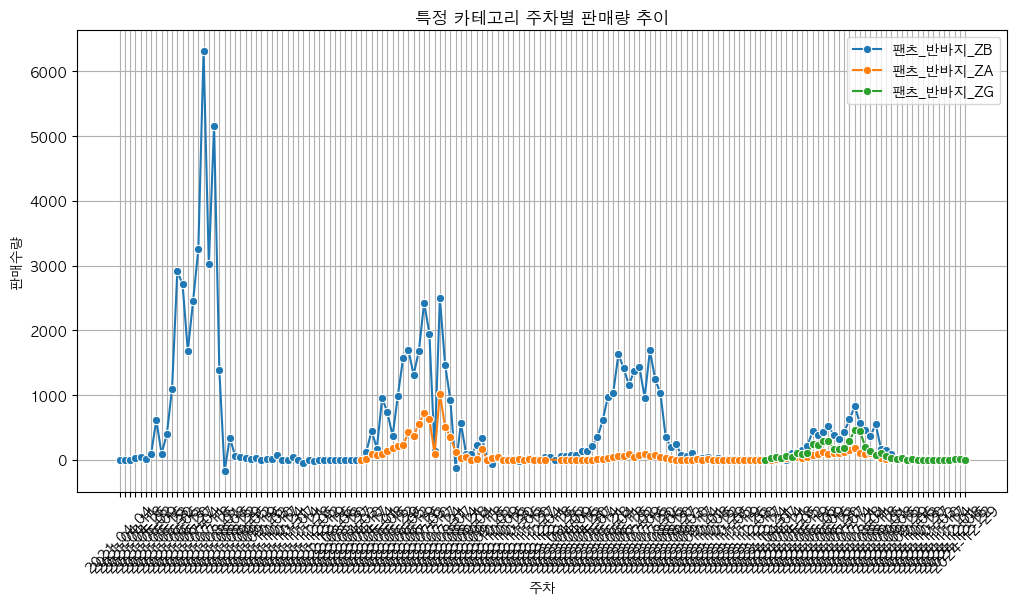

In [14]:
# 카테고리 선택
selected_categories2 = ['팬츠_반바지_ZA', '팬츠_반바지_ZB', '팬츠_반바지_ZG'] 
df_selected = df2[df2["카테고리"].isin(selected_categories2)]

plt.figure(figsize=(12, 6))

# Seaborn 라인 플롯
sns.lineplot(data=df_selected, x="주차", y="판매수량", hue="카테고리", marker="o")

plt.xlabel("주차")
plt.ylabel("판매수량")
plt.title("특정 카테고리 주차별 판매량 추이")
plt.xticks(rotation=45)
plt.grid()
plt.legend()

plt.show()

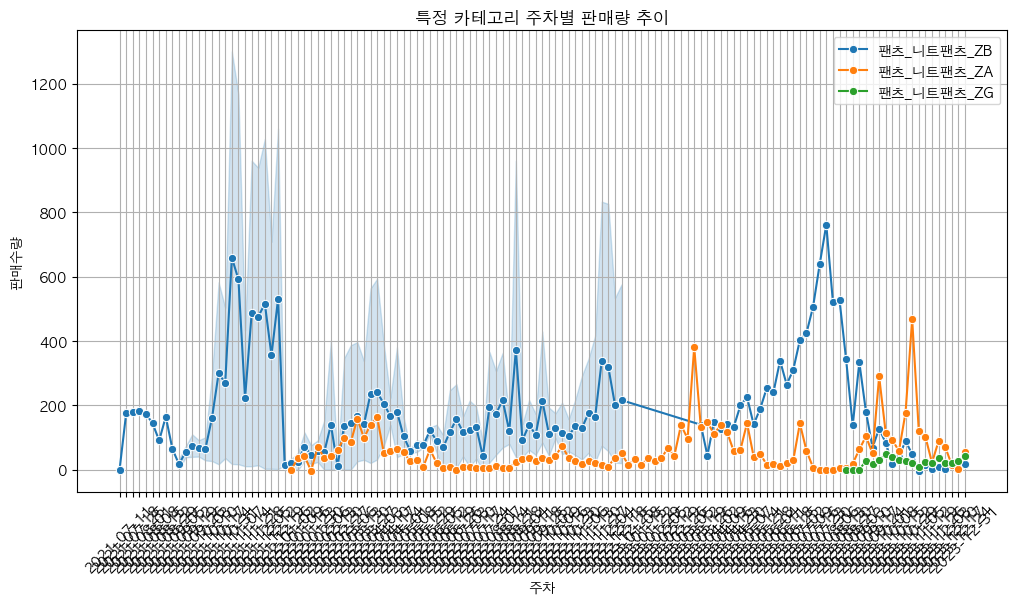

In [15]:
# 카테고리 선택
selected_categories3 = ['팬츠_니트팬츠_ZA', '팬츠_니트팬츠_ZB', '팬츠_니트팬츠_ZG'] 
df_selected = df2[df2["카테고리"].isin(selected_categories3)]

plt.figure(figsize=(12, 6))

# Seaborn 라인 플롯
sns.lineplot(data=df_selected, x="주차", y="판매수량", hue="카테고리", marker="o")

plt.xlabel("주차")
plt.ylabel("판매수량")
plt.title("특정 카테고리 주차별 판매량 추이")
plt.xticks(rotation=45)
plt.grid()
plt.legend()

plt.show()

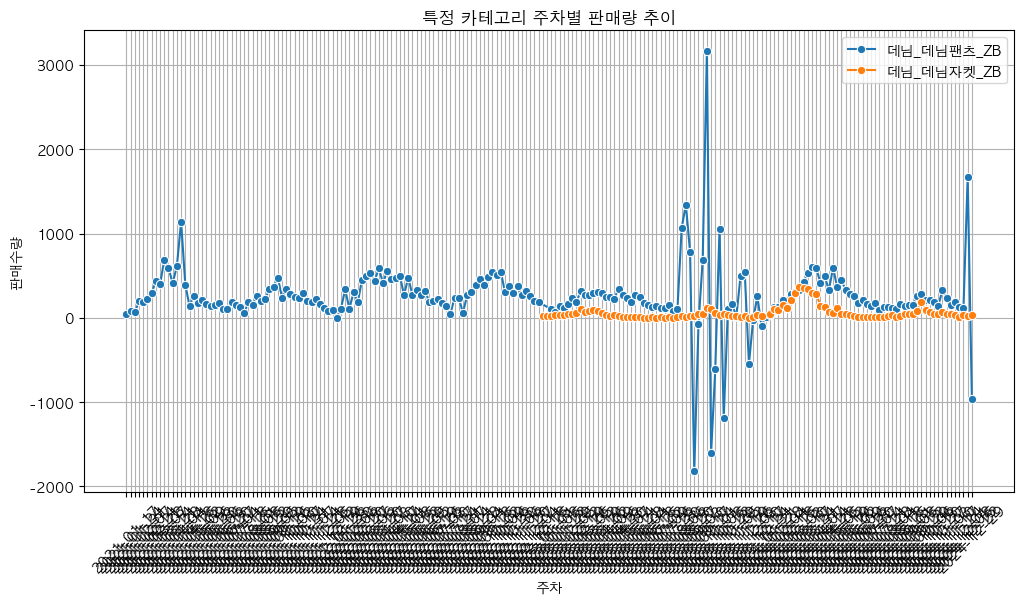

In [16]:
# 카테고리 선택
selected_categories4 = ['데님_데님자켓_ZB', '데님_데님팬츠_ZB'] 
df_selected = df2[df2["카테고리"].isin(selected_categories4)]

plt.figure(figsize=(12, 6))

# Seaborn 라인 플롯
sns.lineplot(data=df_selected, x="주차", y="판매수량", hue="카테고리", marker="o")

plt.xlabel("주차")
plt.ylabel("판매수량")
plt.title("특정 카테고리 주차별 판매량 추이")
plt.xticks(rotation=45)
plt.grid()
plt.legend()

plt.show()

### 소품종 상품별

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# 첫 번째 라인: 판매수량
sns.lineplot(df2["주차"], df2["판매수량"], marker="o", linestyle="-", color="b", label="판매수량")

# 두 번째 라인: 판매액
sns.lineplot(df2["주차"], df2["판매액"], marker="s", linestyle="--", color="r", label="판매액")

plt.xlabel("주차")
plt.ylabel("수량 / 금액")
plt.title("주차별 판매수량 & 판매액 추이")
plt.xticks(rotation=45)
plt.legend()
plt.grid()

plt.show()

TypeError: lineplot() takes from 0 to 1 positional arguments but 2 were given

<Figure size 1200x600 with 0 Axes>

/Users/gim-yeon-a/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/gim-yeon-a/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/gim-yeon-a/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 54032 (\N{HANGUL SYLLABLE PAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/gim-yeon-a/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/gim-yeon-a/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}

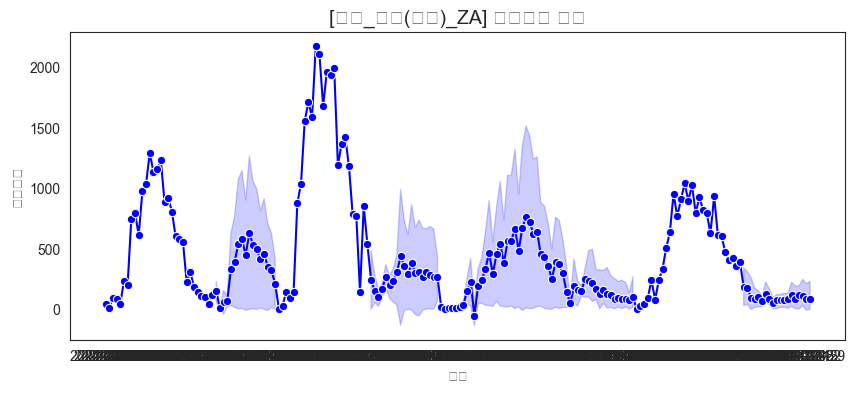

/Users/gim-yeon-a/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/gim-yeon-a/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/gim-yeon-a/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 54032 (\N{HANGUL SYLLABLE PAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/gim-yeon-a/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/gim-yeon-a/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}

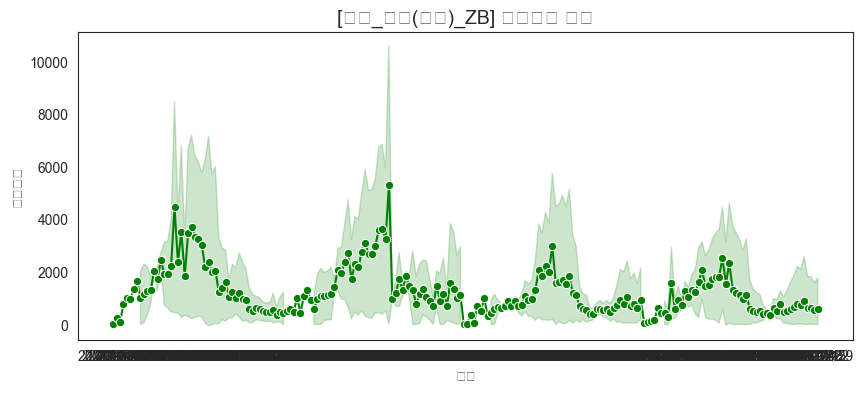

/Users/gim-yeon-a/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/gim-yeon-a/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/gim-yeon-a/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 54032 (\N{HANGUL SYLLABLE PAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/gim-yeon-a/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/gim-yeon-a/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}

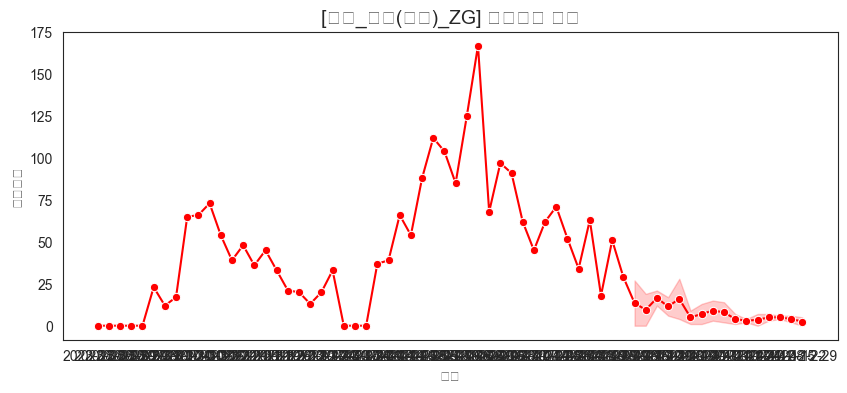

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 분석할 카테고리
category_za = "팬츠_팬츠(일반)_ZA"
category_zb = "팬츠_팬츠(일반)_ZB"
category_zg = "팬츠_팬츠(일반)_ZG"

# 필터링
df_za = df2[df2['카테고리'] == category_za]
df_zb = df2[df2['카테고리'] == category_zb]
df_zg = df2[df2['카테고리'] == category_zg]

# 팬츠_팬츠(일반)_ZA 판매수량 추이
plt.figure(figsize=(10, 4))
sns.lineplot(data=df_za, x='주차', y='판매수량', marker='o', color='b')
plt.title(f"[{category_za}] 판매수량 추이", fontsize=14)
plt.xlabel("주차")
plt.ylabel("판매수량")
plt.show()

# 팬츠_팬츠(일반)_ZB 판매수량 추이
plt.figure(figsize=(10, 4))
sns.lineplot(data=df_zb, x='주차', y='판매수량', marker='o', color='g')
plt.title(f"[{category_zb}] 판매수량 추이", fontsize=14)
plt.xlabel("주차")
plt.ylabel("판매수량")
plt.show()

# 팬츠_팬츠(일반)_ZG 판매수량 추이
plt.figure(figsize=(10, 4))
sns.lineplot(data=df_zg, x='주차', y='판매수량', marker='o', color='r')
plt.title(f"[{category_zg}] 판매수량 추이", fontsize=14)
plt.xlabel("주차")
plt.ylabel("판매수량")
plt.show()